In [1]:
import torch
import pandas as pd
import numpy as np

In [2]:
torch.manual_seed =42

In [9]:
ls -lh images.zip

-rw-r--r-- 1 root root 111M Feb 12 08:01 images.zip


In [10]:
!unzip images.zip -d images

Archive:  images.zip
   creating: images/natural_images/
   creating: images/natural_images/car/
  inflating: images/natural_images/car/car_0000.jpg  
  inflating: images/natural_images/car/car_0001.jpg  
  inflating: images/natural_images/car/car_0002.jpg  
  inflating: images/natural_images/car/car_0003.jpg  
  inflating: images/natural_images/car/car_0004.jpg  
  inflating: images/natural_images/car/car_0005.jpg  
  inflating: images/natural_images/car/car_0006.jpg  
  inflating: images/natural_images/car/car_0007.jpg  
  inflating: images/natural_images/car/car_0008.jpg  
  inflating: images/natural_images/car/car_0009.jpg  
  inflating: images/natural_images/car/car_0010.jpg  
  inflating: images/natural_images/car/car_0011.jpg  
  inflating: images/natural_images/car/car_0012.jpg  
  inflating: images/natural_images/car/car_0013.jpg  
  inflating: images/natural_images/car/car_0014.jpg  
  inflating: images/natural_images/car/car_0015.jpg  
  inflating: images/natural_images/car/

In [53]:
!file images.zip

images.zip: Zip archive data, at least v2.0 to extract, compression method=store


In [65]:
/content/images.zip

NameError: name 'content' is not defined

In [15]:
!unzip -t images.zip

Archive:  images.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of images.zip or
        images.zip.zip, and cannot find images.zip.ZIP, period.


In [11]:
!unzip images.zip -d dataset

Archive:  images.zip
   creating: dataset/natural_images/
   creating: dataset/natural_images/car/
  inflating: dataset/natural_images/car/car_0000.jpg  
  inflating: dataset/natural_images/car/car_0001.jpg  
  inflating: dataset/natural_images/car/car_0002.jpg  
  inflating: dataset/natural_images/car/car_0003.jpg  
  inflating: dataset/natural_images/car/car_0004.jpg  
  inflating: dataset/natural_images/car/car_0005.jpg  
  inflating: dataset/natural_images/car/car_0006.jpg  
  inflating: dataset/natural_images/car/car_0007.jpg  
  inflating: dataset/natural_images/car/car_0008.jpg  
  inflating: dataset/natural_images/car/car_0009.jpg  
  inflating: dataset/natural_images/car/car_0010.jpg  
  inflating: dataset/natural_images/car/car_0011.jpg  
  inflating: dataset/natural_images/car/car_0012.jpg  
  inflating: dataset/natural_images/car/car_0013.jpg  
  inflating: dataset/natural_images/car/car_0014.jpg  
  inflating: dataset/natural_images/car/car_0015.jpg  
  inflating: dataset/

In [12]:
!pip install split-folders

In [13]:
import splitfolders as sp
input_path ='/content/dataset/natural_images'
sp.ratio(input_path,output ='/content/image_dataset',seed =42,ratio =(0.7,0.2,0.1),shuffle =True)

Copying files: 3696 files [00:00, 5073.20 files/s]


In [14]:
from torchvision import datasets,transforms
from torch.utils.data import DataLoader

tarnsform_train = transforms.Compose(
   [ transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
     transforms.ColorJitter(brightness=0.2, contrast=0.2),
     transforms.ToTensor()]
)

transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])


train_data = datasets.ImageFolder(root ='/content/image_dataset/train',transform = tarnsform_train)
test_data = datasets.ImageFolder(root ='/content/image_dataset/test',transform = transforms)
val_data = datasets.ImageFolder(root = '/content/image_dataset/val',transform = transforms)

#Dataloader
train_load = DataLoader(train_data,batch_size=32,shuffle=True)
val_load =DataLoader(val_data,batch_size=32,shuffle = False)
test_load = DataLoader(test_data,batch_size =32,shuffle = False)


In [15]:
len(train_data[0])

2

In [16]:
train_load

In [17]:
images, labels = next(iter(train_load))

print("Images tensor shape:", images.shape)
print("Labels tensor shape:", labels.shape)



print("\nTensor values of first labels:\n", labels[:])

Images tensor shape: torch.Size([32, 3, 224, 224])
Labels tensor shape: torch.Size([32])

Tensor values of first labels:
 tensor([3, 3, 1, 0, 1, 2, 2, 1, 1, 3, 0, 3, 1, 3, 2, 0, 3, 1, 0, 3, 1, 3, 2, 1,
        1, 0, 3, 1, 1, 2, 3, 1])


In [18]:
torch.cuda.is_available()

True

In [19]:
device ='cuda'

In [20]:
import torch.nn as nn
class NeuralNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.features =nn.Sequential(
        nn.Conv2d(3,32,3,padding ='same'),
        nn.BatchNorm2d(32),
        nn.ReLU(),

        nn.Conv2d(32,64,3,padding ='same'),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(64,128,3,padding ='same'),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(128,256,3,padding ='same'),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(256*28*28,256),
        nn.ReLU(),
        nn.Dropout(0.3),

        nn.Linear(256,128),
        nn.ReLU(),
        nn.Dropout(0.3),

        nn.Linear(128,64),
        nn.ReLU(),
        nn.Dropout(0.3),

        nn.Linear(64,32),
        nn.ReLU(),
        nn.Dropout(0.3),

        nn.Linear(32,4)
    )

  def forward(self,x):
    x = self.features(x)
    x= self.classifier(x)
    return x


In [21]:
model =NeuralNetwork()
model = model.to(device)

In [22]:
import torch.optim as optim
#loss funtion
loss_fun = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(),lr =0.001,weight_decay =1e-5)

In [23]:
epochs =18

In [24]:
train_loss =[]
for epoch in range(epochs):
  epoch_loss =0
  total_loss =0
  for (images,labels) in train_load:
    images = images.to(device)
    labels = labels.to(device)

    #forwardpass
    output = model(images)

    #loass
    loss = loss_fun(output,labels)

    #zerogradients
    optimizer.zero_grad()

    #backward
    loss.backward()

    #update
    optimizer.step()
    total_loss +=loss.item()
  avg_loss = total_loss/len(train_load)
  train_loss.append(avg_loss)
  print(f"epoch : {epoch+1}, and loss : {avg_loss}")

epoch : 1, and loss : 1.484110427491459
epoch : 2, and loss : 0.79408883680532
epoch : 3, and loss : 0.6511344538058763
epoch : 4, and loss : 0.5937692493568232
epoch : 5, and loss : 0.6313966545793745
epoch : 6, and loss : 0.6024985317094826
epoch : 7, and loss : 0.5647752402741232
epoch : 8, and loss : 0.5281939469737771
epoch : 9, and loss : 0.493426674310072
epoch : 10, and loss : 0.48832269528029876
epoch : 11, and loss : 0.4941223237985446
epoch : 12, and loss : 0.42184586142316277
epoch : 13, and loss : 0.3752816367296525
epoch : 14, and loss : 0.3391363357688174
epoch : 15, and loss : 0.3796636739998688
epoch : 16, and loss : 0.285178544068778
epoch : 17, and loss : 0.27960369919921146
epoch : 18, and loss : 0.2506558997211633


In [25]:
model.eval()
correct=0
total=0

for (images,labels) in train_load:
  images = images.to(device)
  labels = labels.to(device)

  output = model(images)
  _,predicted = torch.max(output,1)
  correct +=(predicted==labels).sum().item()
  total += labels.size(0)
train_acc =correct/total
print("Train Accuracy:", train_acc)

Train Accuracy: 0.9516627996906419


In [26]:
model.eval()
correct =0
total =0

for (images,labels) in val_load:
  images = images.to(device)
  labels = labels.to(device)

  output = model(images)
  _,predicted = torch.max(output,1)
  correct +=(predicted==labels).sum().item()
  total += labels.size(0)
val_acc =correct/total
print("Validation Accuracy:", val_acc)

Validation Accuracy: 0.943089430894309


In [27]:
model.eval()
correct =0
total =0

for (images,labels) in test_load:
  images = images.to(device)
  labels = labels.to(device)

  output = model(images)
  _,predicted = torch.max(output,1)
  correct +=(predicted==labels).sum().item()
  total += labels.size(0)
test_acc =correct/total
print("Test Accuracy:", test_acc)

Test Accuracy: 0.9327956989247311


In [28]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_load:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [29]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Accuracy:", accuracy_score(all_labels, all_preds))

Accuracy: 0.9327956989247311


In [30]:
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.86      0.98      0.91        98
           1       0.90      0.83      0.87        89
           2       1.00      0.91      0.95        85
           3       0.99      1.00      1.00       100

    accuracy                           0.93       372
   macro avg       0.94      0.93      0.93       372
weighted avg       0.94      0.93      0.93       372



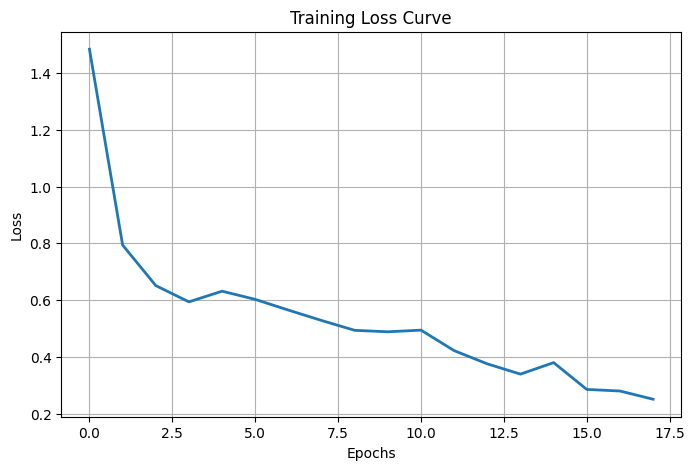

In [31]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_loss, linewidth=2)
plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()
